# Extract EHRFormer Embeddings

In [1]:
import sys
sys.path.insert(0, '../lib')

In [ ]:
import warnings
import numpy as np
import torch
import pandas as pd
import pickle
from datasets import Dataset
from transformers import BertForMaskedLM, BertConfig, BertForSequenceClassification
import umap
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pathlib

import common_data

In [ ]:
# TORCH MISC
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
BATCH_SIZE = 16

# DATA MISC
NB_OF_BINS = 4 + 1 # Number of bins into which data values were binned (4) + 1 for NA

IS_NA_BIN_NAME = 'binis_na' # Name of the column for NA bin, this changed because of quartile binning

# PATH MISC
EHR_FILE_PATH = common_data.EHRFORMER_BINS

PATOGENE_LABELS_PATH = common_data.CLINICAL_LABELS

# TOKEN_MISC
CLS_TOKEN = 0
MASK_TOKEN = 1

In [4]:
%config InlineBackend.figure_format = "retina"

In [5]:
pd.options.display.max_columns = 300

In [6]:
mpl.rcParams["pdf.fonttype"] = 42

## 1. Prepare Dataset and Tokens

In [7]:
with open(EHR_FILE_PATH, 'rb') as pickle_handle:
    ehr_df = pickle.load(pickle_handle)

In [8]:
ehr_df.shape

(15287, 250)

## 1.1 Checks

Which features don't have 5 bins?

In [9]:
ehr_df.columns.to_frame().groupby(0).size().ne(5).replace({False: np.nan}).dropna()

Series([], dtype: float64)

Ok, good, moving forward

How many features? and which

In [10]:
ehr_df.columns.to_frame()[0].nunique()

50

## 1.2 Prepare dataset

Define vocab

In [11]:
# Define vocab
VOCAB = {
    "CLS": CLS_TOKEN,
    "MASK": MASK_TOKEN,
    **{
        f'bin{ind_}': ind_ + 2 for ind_ in range(NB_OF_BINS - 1)
    },
    IS_NA_BIN_NAME: NB_OF_BINS + 2 - 1
}

In [12]:
labels_df = pd.read_csv(PATOGENE_LABELS_PATH)

In [13]:
ehr_bins = [
    [
        column_name[1]
        for column_name, column_value in zip(ehr_df.columns, row_)
        if column_value
    ]
    for row_nb, row_ in ehr_df.iterrows()
]

In [14]:
ehr_row_tokens_all = [
    [VOCAB[token] for token in ehr_row]
    for ehr_row in ehr_bins
]

ehr_row_dataset_all = Dataset.from_dict({'input_ids': ehr_row_tokens_all})

## 1.3 Data Collator

In [ ]:
class EHRSequenceClassificationFormerDataCollator:
    def __init__(
        self,
        cls_token=CLS_TOKEN,
        mask_token=MASK_TOKEN,
    ):
        self.cls_token = cls_token
        self.mask_token = mask_token

    def __call__(self, ehrs):
        tokens = torch.tensor([
            [self.cls_token] + ehr_row['input_ids']
            for ehr_row in ehrs
        ])
        return {
            'input_ids': tokens
        }

## 2. Load pretrained model

We're using pretrained model from one of the tasks and splits

In [ ]:
MODEL = 'vap_outcome_test_split_4'
MODEL_BASE_PATH = pathlib.Path('../data/01_ehrformer/models/pretrained/')
model = BertForSequenceClassification.from_pretrained(
    MODEL,
    output_hidden_states=True
)

## 2.1 Patient-Day embeddings

In [25]:
data_collator = EHRSequenceClassificationFormerDataCollator()

input_tensor = data_collator(ehr_row_dataset_all)

In [ ]:
with torch.no_grad():
    result = model(input_tensor['input_ids'])

In [ ]:
print(result.keys())
print(result['logits'].shape)
print(len(result['hidden_states']))
print(result['hidden_states'][0].shape)

odict_keys(['logits', 'hidden_states'])
torch.Size([15287, 2])
5
torch.Size([15287, 51, 64])


Save embeddings

In [ ]:
pickle.dump(result, open('04_embeddings_outputs.pickle', 'wb'))

Deriving patient-day embeddings from **penultimate layer**, excluding CLS token

### Mean Pooling vs CLS Token Embedding
The choice between these two approaches often depends on the specific use case and downstream task. Mean pooling provides a way to capture the overall information from a sequence, whereas directly using the [CLS] token embedding might be suitable for tasks where the [CLS] token is designed to capture the entire sequence's representation, as is common in tasks like text classification.

Let's remove `[CLS]` token from Mean pooling

In [ ]:
last_hidden_states = result['hidden_states'][-2]
embeddings = last_hidden_states[:, 1:, :].mean(axis=1).detach().numpy()
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    umap_model = umap.UMAP(n_components=2, random_state=1039, min_dist=0.1, spread=0.5, n_neighbors=8)
    umap_pt_day_embedding = umap_model.fit_transform(embeddings)

In [ ]:
ehr_data = pd.read_csv(common_data.CLINICAL, index_col=0)

In [ ]:
full_df = labels_df.merge(ehr_data, left_index=True, right_index=True, suffixes=('', '_ehr'))

In [ ]:
full_df['day_of_hospitalization_log'] = np.log(full_df['day_of_hospitalization'])

In [ ]:
plot_df = full_df.copy()
plot_df['UMAP1'] = umap_pt_day_embedding[:, 0]
plot_df['UMAP2'] = umap_pt_day_embedding[:, 1]

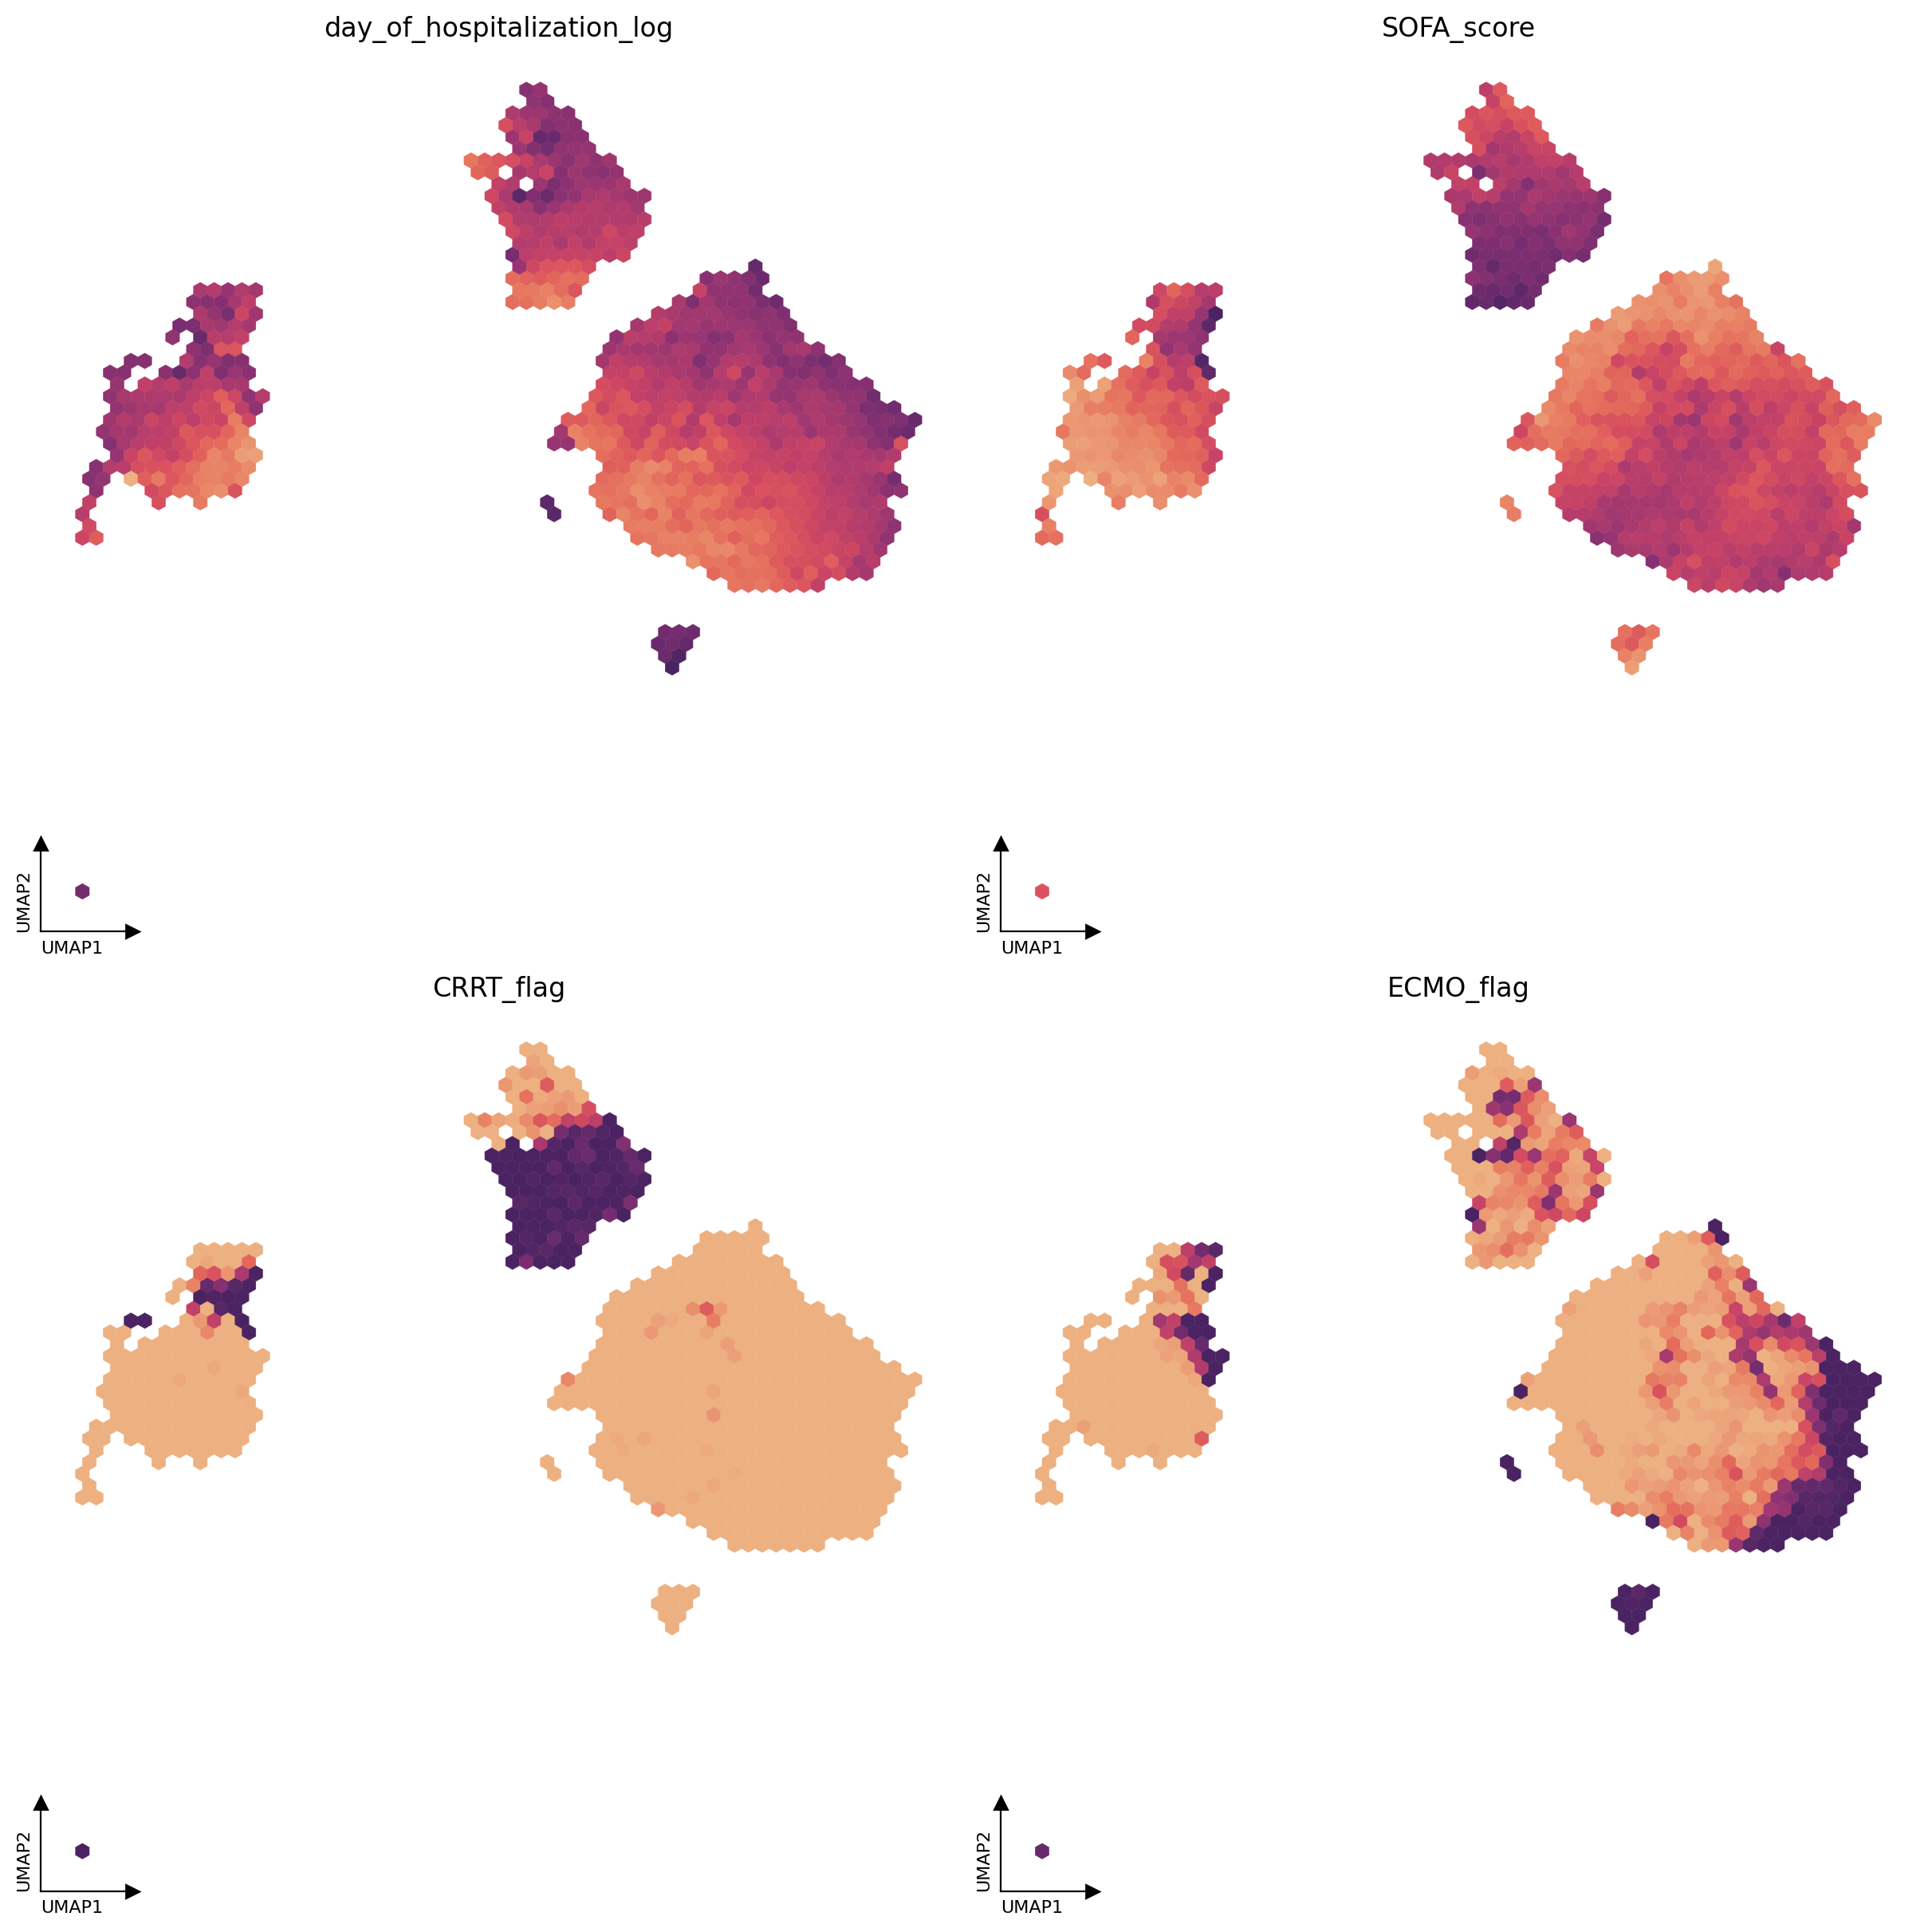

In [ ]:
TO_PLOT = ['day_of_hospitalization_log', 'SOFA_score', 'CRRT_flag', 'ECMO_flag']
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)
axes = axes.flatten()
for i, col in enumerate(TO_PLOT):
    # Hexbin plot of embeddings
    ax = axes[i]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        hex_plot = ax.hexbin(
            x=plot_df['UMAP1'],
            y=plot_df['UMAP2'],
            C=plot_df[col],

            gridsize=60,
            cmap='flare',
            linewidths=0.15,
        )
    # Style axes similar to the existing plots
    shrink_by = 0.1
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xbound = xlim[0] + (xlim[1] - xlim[0]) * shrink_by
    ybound = ylim[0] + (ylim[1] - ylim[0]) * shrink_by
    b = ax.spines["bottom"]
    b.set_bounds(xlim[0], xbound)
    ax.set_xlabel('UMAP1', x=0, ha="left", fontsize=8)
    ax.plot(xbound, 0, ">k", transform=ax.get_xaxis_transform(), clip_on=False)
    b = ax.spines["left"]
    b.set_bounds(ylim[0], ybound)
    ax.set_ylabel('UMAP2', y=0, ha="left", fontsize=8)
    ax.plot(0, ybound, "^k", transform=ax.get_yaxis_transform(), clip_on=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(left=False, labelleft=False, bottom=False, labelbottom=False)
    ax.set_title(col, fontsize=12)

In [ ]:
pd.DataFrame(umap_pt_day_embedding, columns=['umap1', 'umap2'], index=full_df.index).to_csv(
    '04_embeddings_umap.csv'
)